# DNEMD Analysis output processing

<function matplotlib.pyplot.show(close=None, block=None)>

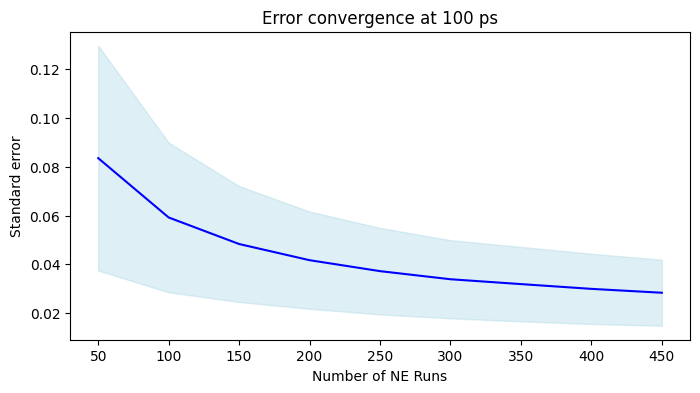

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#A Jupyter notebook to plot the outputs of NullP.py, analysing the response of EGFR upon removal of an inhibitor (PREVIOUS D-NEMD STUDY FROM WITHIN THE GROUP)

#############################################################
#The analysis written in here is mine, the results are not.##
#############################################################

picos_dfs = {} #A dictionary to contain the pandas dataframes made for 100 ps at each number of runs

columns = ["CA_index", "avg_x", "avg_y", "avg_z", "n_x", "n_y", "n_z", "avg_disp", "se_x", "se_y", "se_z", "se_mag", "sd2_x", "sd2_y", "sd2_z", "sd2_mag"]

for n in range(10, 100, 10):
    filename = f"Outputs_NullP/{n}Elements/vec_norm_stats_100_NullP_wt1SD.txt"
    picos_df = pd.read_csv(filename, sep='\s+', comment='#', header=None)
    picos_df.columns = columns
    picos_dfs[f"{n}_df"] = picos_df 

#To access do picos_dfs["10_df"], picos_dfs["50_df"]

se_average_list = [picos_dfs[f"{n}_df"]["se_mag"].mean() for n in range(10, 100, 10)]
se_std_list = [picos_dfs[f"{n}_df"]["se_mag"].std() for n in range(10, 100, 10)]
element_list = 5*(np.arange(10, 100, 10))

plt.figure(figsize=(8, 4))
plt.plot(element_list, se_average_list, color = 'blue')
plt.fill_between(element_list, np.array(se_average_list)-np.array(se_std_list), np.array(se_average_list)+np.array(se_std_list), alpha = 0.4, color = 'lightblue')
plt.xlabel("Number of NE Runs")
plt.ylabel("Standard error")
plt.title("Error convergence at 100 ps")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

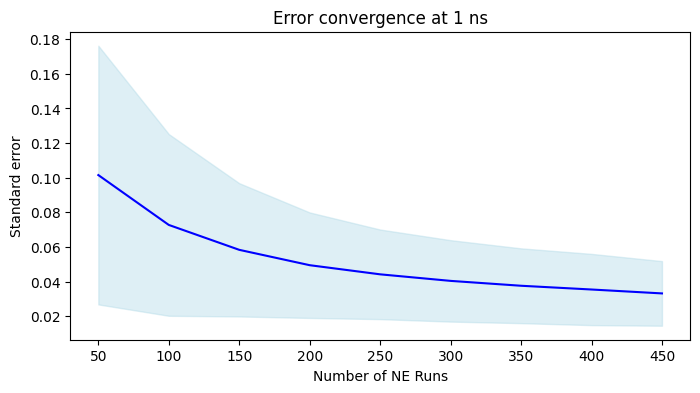

In [2]:


one_dfs = {} #A dictionary to contain the pandas dataframes made for 1 ns at each number of runs

for n in range(10, 100, 10):
    filename = f"Outputs_NullP/{n}Elements/vec_norm_stats_1000_NullP_wt1SD.txt"
    one_df = pd.read_csv(filename, sep='\s+', comment='#', header=None)
    one_df.columns = columns
    one_dfs[f"{n}_df"] = one_df 

se_average_list = [one_dfs[f"{n}_df"]["se_mag"].mean() for n in range(10, 100, 10)]
se_std_list = [one_dfs[f"{n}_df"]["se_mag"].std() for n in range(10, 100, 10)]
element_list = 5*(np.arange(10, 100, 10))

plt.figure(figsize=(8, 4))
plt.plot(element_list, se_average_list, color = 'blue')
plt.fill_between(element_list, np.array(se_average_list)-np.array(se_std_list), np.array(se_average_list)+np.array(se_std_list), alpha = 0.4, color = 'lightblue')
plt.xlabel("Number of NE Runs")
plt.ylabel("Standard error")
plt.title("Error convergence at 1 ns")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

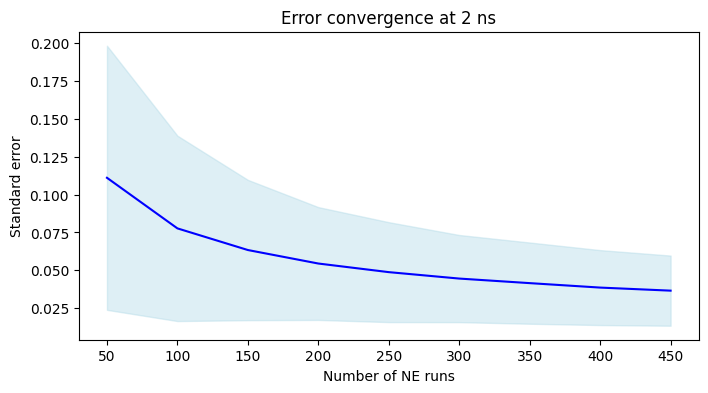

In [3]:
two_dfs = {}

for n in range(10, 100, 10):
    filename = f"Outputs_NullP/{n}Elements/vec_norm_stats_2000_NullP_wt1SD.txt"
    two_df = pd.read_csv(filename, sep='\s+', comment='#', header=None)
    two_df.columns = columns
    two_dfs[f"{n}_df"] = two_df 


se_average_list = [two_dfs[f"{n}_df"]["se_mag"].mean() for n in range(10, 100, 10)]
se_std_list = [two_dfs[f"{n}_df"]["se_mag"].std() for n in range(10, 100, 10)]

plt.figure(figsize=(8, 4))
plt.plot(element_list, se_average_list, color = 'blue')
plt.fill_between(element_list, np.array(se_average_list)-np.array(se_std_list), np.array(se_average_list)+np.array(se_std_list), alpha = 0.4, color = 'lightblue')
plt.xlabel("Number of NE runs")
plt.ylabel("Standard error")
plt.title("Error convergence at 2 ns")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

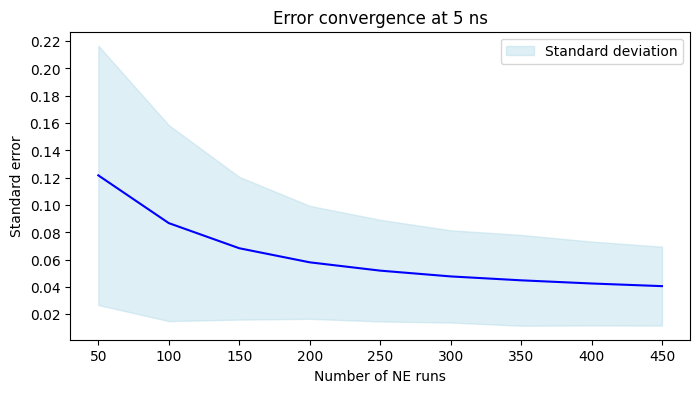

In [14]:
from matplotlib.ticker import MultipleLocator
five_dfs = {}

for n in range(10, 100, 10):
    filename = f"Outputs_NullP/{n}Elements/vec_norm_stats_5000_NullP_wt1SD.txt"
    five_df = pd.read_csv(filename, sep='\s+', comment='#', header=None)
    five_df.columns = columns
    five_dfs[f"{n}_df"] = five_df 

se_average_list = [five_dfs[f"{n}_df"]["se_mag"].mean() for n in range(10, 100, 10)]
se_std_list = [five_dfs[f"{n}_df"]["se_mag"].std() for n in range(10, 100, 10)]

plt.figure(figsize=(8, 4))
plt.plot(element_list, se_average_list, color = 'blue')
plt.fill_between(element_list, np.array(se_average_list) - np.array(se_std_list), np.array(se_average_list)+ np.array(se_std_list), alpha = 0.4, color = 'lightblue', label = "Standard deviation")
plt.gca().yaxis.set_major_locator(MultipleLocator(0.02))
plt.xlabel("Number of NE runs")
plt.ylabel("Standard error")
plt.title("Error convergence at 5 ns")
plt.legend()
plt.savefig("Errorconvergenceat5ns.png")
plt.show


It seems to me like the standard error appears to converge nicely at around 50 elements/ 250 runs. Therefore I will run residues and displacements for this.

In [5]:
filename1 = "Outputs_NullP/50Elements/vec_norm_stats_100_NullP_wt1SD.txt"
filename2 = "Outputs_NullP/50Elements/vec_norm_stats_1000_NullP_wt1SD.txt"
filename3 = "Outputs_NullP/50Elements/vec_norm_stats_2000_NullP_wt1SD.txt"
filename4 = "Outputs_NullP/50Elements/vec_norm_stats_5000_NullP_wt1SD.txt"

pointone = pd.read_csv(filename1, sep='\s+', comment='#', header=None)
pointone.columns = columns 
onenano = pd.read_csv(filename2, sep='\s+', comment='#', header=None)
onenano.columns = columns 
twonano = pd.read_csv(filename3, sep='\s+', comment='#', header=None)
twonano.columns = columns 
fivenano = pd.read_csv(filename4, sep='\s+', comment='#', header=None)
fivenano.columns = columns 
c_a_number = np.arange(694, 1020, 1)

<function matplotlib.pyplot.show(close=None, block=None)>

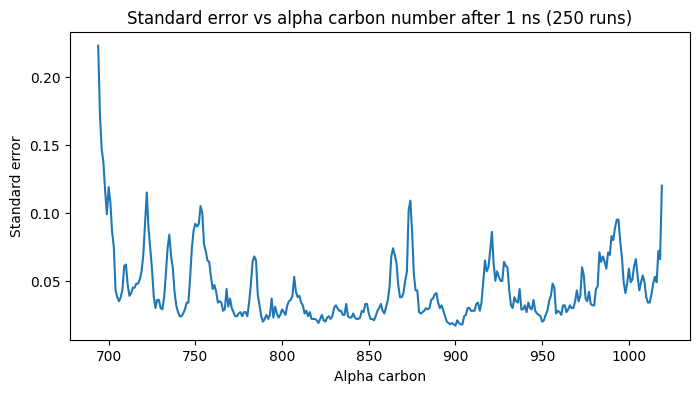

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(c_a_number, onenano["se_mag"])
plt.xlabel("Alpha carbon")
plt.ylabel("Standard error")
plt.title("Standard error vs alpha carbon number after 1 ns (250 runs)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

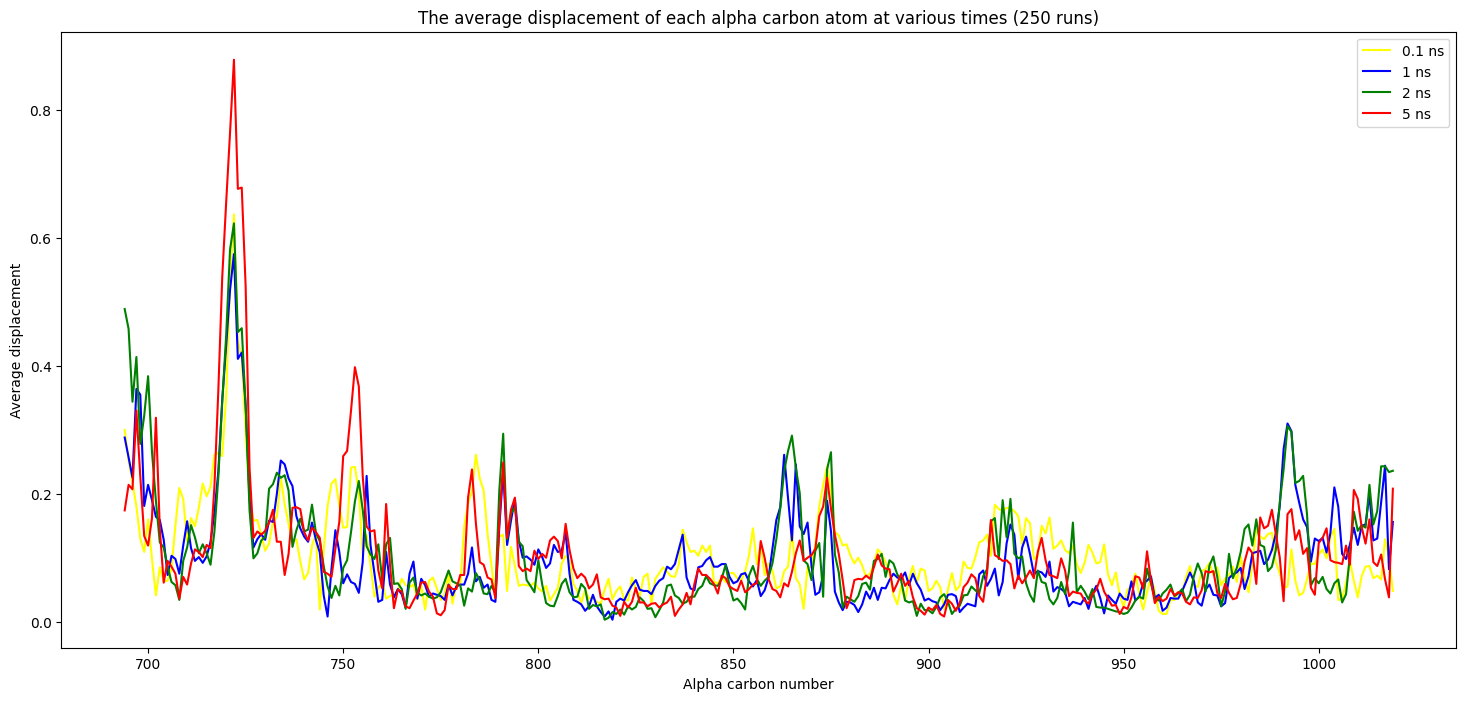

In [ ]:
#Plot to show evolution of signal with time
plt.figure(figsize=(18, 8))
plt.plot(c_a_number, pointone["avg_disp"], color = "yellow", label = "0.1 ns")
plt.plot(c_a_number, onenano["avg_disp"], color = "blue", label = "1 ns")
plt.plot(c_a_number, twonano["avg_disp"], color = "green", label = "2 ns")
plt.plot(c_a_number, fivenano["avg_disp"], color = "red", label = "5 ns")
plt.xlabel("Alpha carbon number")
plt.ylabel("Average displacement")
plt.title("The average displacement of each alpha carbon atom at various times (250 runs)")
plt.legend(loc="upper right")
plt.show